# 🧠🤖 第6周-Day3：ReAct模式与多Agent协作

今天我们来学习AI Agent开发中的两个重要概念：ReAct推理行动模式和多Agent协作系统。这两个概念是现代复杂AI系统的核心架构。

## 🎯 学习目标
- 理解ReAct模式的推理-行动循环
- 掌握多Agent系统的设计和实现
- 通过代码示例直观感受这些概念

In [2]:
# 配置 matplotlib 中文显示
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import shutil

# 清除 matplotlib 字体缓存
cache_dir = matplotlib.get_cachedir()
for item in os.listdir(cache_dir):
    if item.startswith('fontlist'):
        path = os.path.join(cache_dir, item)
        try:
            if os.path.isfile(path):
                os.remove(path)
            elif os.path.isdir(path):
                shutil.rmtree(path)
        except (PermissionError, OSError) as e:
            print(f'⚠️ 无法删除字体缓存 {item}: {e}')

# 重新构建字体列表
fm._load_fontmanager(try_read_cache=False)

# 验证字体是否存在
available_fonts = [f.name for f in fm.fontManager.ttflist]
preferred_fonts = ['WenQuanYi Zen Hei', 'DejaVu Sans']
selected_fonts = [f for f in preferred_fonts if f in available_fonts]

if not selected_fonts:
    print('❌ 警告：未找到可用的中文字体！')
else:
    print(f'✅ 使用中文字体: {selected_fonts[0]}')

# 配置中文字体
plt.rcParams['font.sans-serif'] = selected_fonts
plt.rcParams['axes.unicode_minus'] = False
print('✅ 中文字体配置完成')

# 导入必要的库
import numpy as np
import json
from typing import List, Dict, Any

✅ 使用中文字体: WenQuanYi Zen Hei
✅ 中文字体配置完成


## 🔍 ReAct模式详解

ReAct（Reasoning + Acting）是一种让AI在推理过程中与外界交互的模式。它不是纯粹的思考，也不是盲目的行动，而是思考-行动-观察的循环过程。

In [3]:
# 实现一个简单的ReAct推理示例
class ReactAgent:
    def __init__(self, name="ReAct智能助手"):
        self.name = name
        self.thought_history = []
        self.action_history = []
        self.observation_history = []
    
    def think(self, question: str, available_tools: List[str]) -> str:
        """推理步骤：分析问题，决定需要什么工具"""
        thought = f"🤔 我需要解决: '{question}'"
        available_tools_str = f"可用工具: {', '.join(available_tools)}"
        tool_decision = f"💭 根据问题，我选择使用: {available_tools[0]}"
        
        thought = thought + "\n" + available_tools_str + "\n" + tool_decision
        self.thought_history.append(thought)
        return tool_decision
    
    def act(self, tool: str, tool_input: str) -> str:
        """行动步骤：执行工具调用"""
        action = f"🔧 执行工具: {tool}({tool_input})"
        self.action_history.append(action)
        
        # 模拟工具执行结果
        if tool == "搜索":
            observation = f"📋 搜索结果: 找到关于'{tool_input}'的信息..."
        elif tool == "计算":
            try:
                result = eval(tool_input)
                observation = f"🧮 计算结果: {result}"
            except:
                observation = f"❌ 计算错误: 无法计算'{tool_input}'"
        else:
            observation = f"✅ 工具 '{tool}' 执行完成"
        
        self.observation_history.append(observation)
        return observation
    
    def react_cycle(self, question: str, available_tools: List[str]) -> str:
        """完整的ReAct循环"""
        result = f"🎯 开始ReAct循环...\n\n"
        
        # 第一步：思考
        thought_result = self.think(question, available_tools)
        result += f"【思考】{thought_result}\n\n"
        
        # 第二步：行动
        action_result = self.act(available_tools[0], question)
        result += f"【行动】{action_result}\n\n"
        
        # 第三步：观察结果
        result += f"【观察】{self.observation_history[-1]}\n\n"
        
        # 第四步：最终推理
        final_thought = "🎉 根据观察结果，我得出最终结论..."
        self.thought_history.append(final_thought)
        result += f"【结论】{final_thought}"
        
        return result

# 测试ReAct模式
react_agent = ReactAgent()
available_tools = ["搜索", "计算", "翻译"]
question = "北京今天的天气怎么样？"

result = react_agent.react_cycle(question, available_tools)
print(result)

🎯 开始ReAct循环...

【思考】💭 根据问题，我选择使用: 搜索

【行动】📋 搜索结果: 找到关于'北京今天的天气怎么样？'的信息...

【观察】📋 搜索结果: 找到关于'北京今天的天气怎么样？'的信息...

【结论】🎉 根据观察结果，我得出最终结论...


📊 ReAct循环可视化：


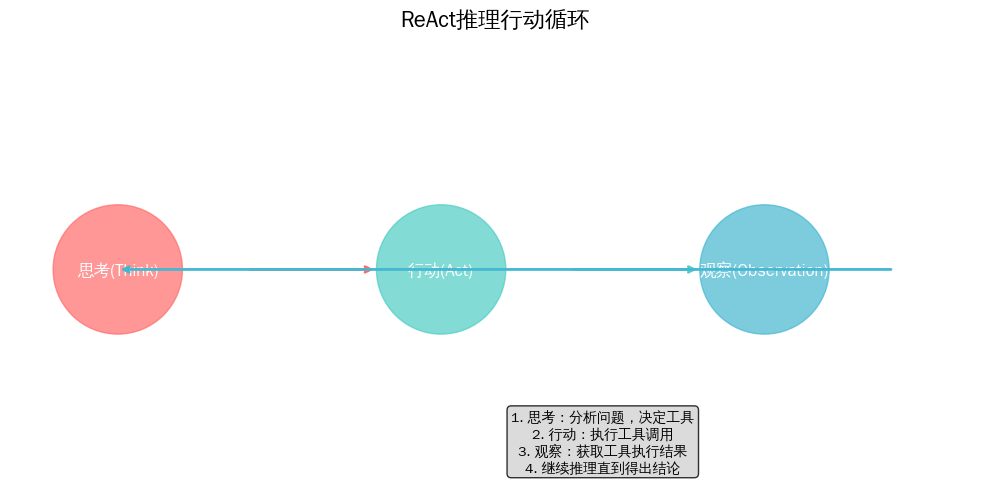


📊 Chain-of-Thought vs ReAct对比：


/tmp/ipykernel_454021/3585748965.py:86: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_454021/3585748965.py:86: UserWarning: Glyph 128173 (\N{THOUGHT BALLOON}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_454021/3585748965.py:86: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_454021/3585748965.py:86: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/tmp/ipykernel_454021/3585748965.py:86: UserWarning: Glyph 128065 (\N{EYE}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/

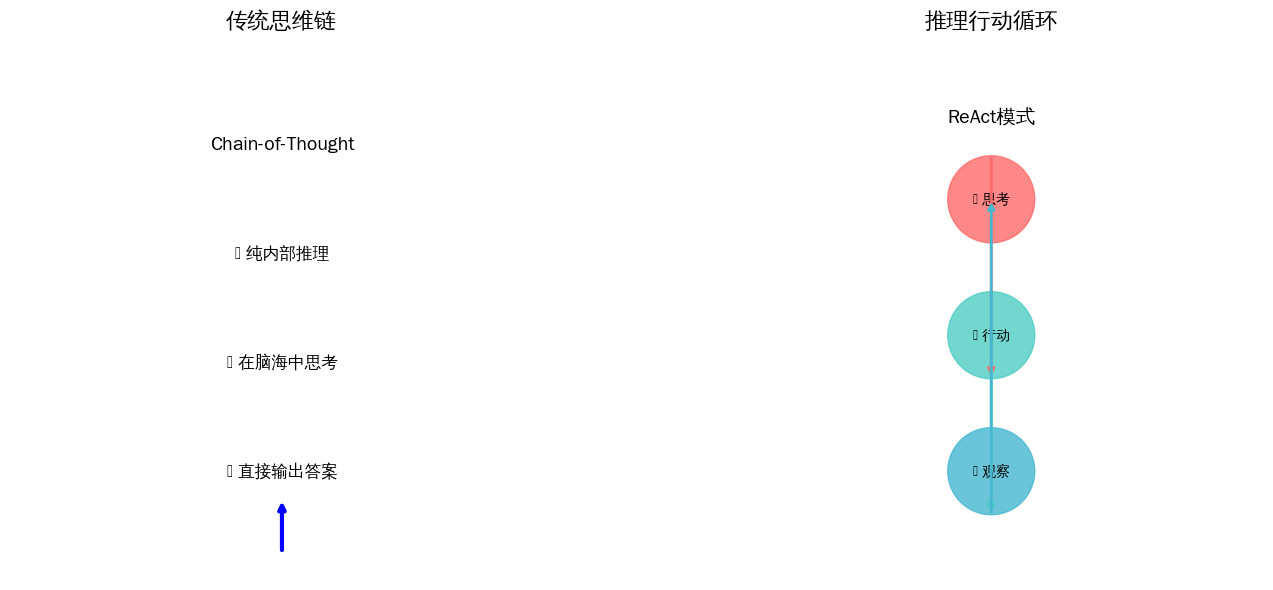

In [4]:
# 可视化ReAct循环过程
def plot_react_cycle():
    """可视化ReAct循环的三个步骤"""
    steps = ['思考(Think)', '行动(Act)', '观察(Observation)']
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 创建循环图
    for i, (step, color) in enumerate(zip(steps, colors)):
        x = i * 1.5
        circle = plt.Circle((x, 0), 0.3, color=color, alpha=0.7)
        ax.add_patch(circle)
        ax.text(x, 0, step, ha='center', va='center', fontsize=12, fontweight='bold', color='white')
        
        # 添加箭头
        if i < len(steps) - 1:
            ax.annotate('', xy=(x + 1.2, 0), xytext=(x + 0.6, 0),
                       arrowprops=dict(arrowstyle='->', lw=2, color=color))
        else:
            # 从最后一个回到第一个
            ax.annotate('', xy=(0, 0), xytext=(x + 0.6, 0),
                       arrowprops=dict(arrowstyle='->', lw=2, color=color))
    
    ax.set_xlim(-0.5, len(steps) * 1.5 - 0.5)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('ReAct推理行动循环', fontsize=16, fontweight='bold', pad=20)
    
    # 添加说明文字
    explanation = "1. 思考：分析问题，决定工具\n2. 行动：执行工具调用\n3. 观察：获取工具执行结果\n4. 继续推理直到得出结论"
    ax.text(len(steps) * 1.5 / 2, -0.8, explanation, ha='center', va='center', 
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# 可视化ReAct与传统Chain-of-Thought的区别
def plot_cot_vs_react():
    """对比Chain-of-Thought和ReAct模式"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Chain-of-Thought
    ax1.text(0.5, 0.8, 'Chain-of-Thought', ha='center', va='center', fontsize=14, fontweight='bold', transform=ax1.transAxes)
    ax1.text(0.5, 0.6, '🧠 纯内部推理', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.text(0.5, 0.4, '💭 在脑海中思考', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.text(0.5, 0.2, '🎯 直接输出答案', ha='center', va='center', fontsize=12, transform=ax1.transAxes)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_aspect('equal')
    ax1.axis('off')
    ax1.set_title('传统思维链', fontsize=16, fontweight='bold')
    
    # 添加箭头
    ax1.annotate('', xy=(0.5, 0.15), xytext=(0.5, 0.05),
                 arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
    
    # ReAct
    ax2.text(0.5, 0.85, 'ReAct模式', ha='center', va='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)
    
    # 绘制ReAct循环
    cycle_steps = ['🧠 思考', '🔧 行动', '👁 观察']
    y_positions = [0.7, 0.45, 0.2]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for i, (step, y_pos, color) in enumerate(zip(cycle_steps, y_positions, colors)):
        circle = plt.Circle((0.5, y_pos), 0.08, color=color, alpha=0.8)
        ax2.add_patch(circle)
        ax2.text(0.5, y_pos, step, ha='center', va='center', fontsize=10, fontweight='bold', transform=ax2.transAxes)
        
        if i < len(cycle_steps) - 1:
            ax2.annotate('', xy=(0.5, y_positions[i+1] - 0.08), xytext=(0.5, y_pos + 0.08),
                        arrowprops=dict(arrowstyle='->', lw=2, color=color))
        else:
            # 循环回来
            ax2.annotate('', xy=(0.5, 0.7), xytext=(0.5, 0.12),
                        arrowprops=dict(arrowstyle='->', lw=2, color=color))
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('推理行动循环', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# 执行可视化
print("📊 ReAct循环可视化：")
plot_react_cycle()

print("\n📊 Chain-of-Thought vs ReAct对比：")
plot_cot_vs_react()

## 🤝 多Agent协作系统

多Agent系统就像是AI世界中的团队合作，每个Agent负责特定领域，通过有效协作完成复杂任务。

In [5]:
# 实现一个简单的多Agent协作系统
class Agent:
    def __init__(self, name: str, role: str, capabilities: List[str]):
        self.name = name
        self.role = role
        self.capabilities = capabilities
        self.completed_tasks = []
    
    def execute_task(self, task: str) -> str:
        """执行任务"""
        if any(cap in task for cap in self.capabilities):
            result = f"✅ {self.name}({self.role}) 正在处理: {task}\n"
            result += f"🎯 使用能力: {', '.join(self.capabilities)}\n"
            result += f"📋 完成时间: {np.random.randint(1, 5)}分钟\n"
            result += f"🏆 任务完成!"
            self.completed_tasks.append(task)
            return result
        else:
            return f"❌ {self.name}无法处理任务: {task} (能力不匹配)"

class MultiAgentSystem:
    def __init__(self, name: str):
        self.name = name
        self.agents = []
        self.task_queue = []
    
    def add_agent(self, agent: Agent):
        """添加Agent到系统中"""
        self.agents.append(agent)
        print(f"🤖 已添加Agent: {agent.name} ({agent.role})")
    
    def assign_tasks(self, tasks: List[str]) -> List[str]:
        """分配任务给合适的Agent"""
        self.task_queue = tasks.copy()
        results = []
        
        print(f"🎯 开始分配 {len(tasks)} 个任务给 {len(self.agents)} 个Agent...\n")
        
        for task in tasks:
            assigned = False
            
            for agent in self.agents:
                if any(cap in task for cap in agent.capabilities):
                    result = agent.execute_task(task)
                    results.append(f"{agent.name}: {task} → {result.split('🏆')[0].strip()}")
                    assigned = True
                    break
            
            if not assigned:
                results.append(f"⚠️ 任务无人处理: {task}")
        
        return results

    def get_system_summary(self) -> str:
        """获取系统整体状态"""
        summary = f"🏗️ {self.name} 系统状态:\n\n"
        summary += f"📊 Agent总数: {len(self.agents)}\n"
        summary += f"🎯 总任务数: {len(self.task_queue)}\n\n"
        
        summary += "🤖 Agent列表:\n"
        for agent in self.agents:
            summary += f"  • {agent.name} ({agent.role}) - {', '.join(agent.capabilities)}\n"
        
        return summary

# 创建糖水店多Agent系统
def create_tea_shop_system():
    """创建糖水店多Agent系统"""
    system = MultiAgentSystem("美华糖水店智能系统")
    
    # 添加不同角色的Agent
    agents = [
        Agent("小接单", "订单处理", ["接单", "下单", "订单管理"]),
        Agent("小库存", "库存管理", ["库存查询", "补货提醒", "食材管理"]),
        Agent("小推荐", "智能推荐", ["菜品推荐", "个性化建议", "口味分析"]),
        Agent("小结算", "支付结算", ["收款", "找零", "订单结算"])
    ]
    
    for agent in agents:
        system.add_agent(agent)
    
    return system

# 测试多Agent系统
print("🏪 创建糖水店多Agent系统：")
tea_shop_system = create_tea_shop_system()
print(tea_shop_system.get_system_summary())

print("\n🎯 分配实际任务：")
tasks = [
    "顾客点单：一份红豆沙，一份绿豆沙",
    "查询红豆沙库存是否充足",
    "根据顾客历史记录推荐新饮品",
    "处理支付：微信收款25元"
]

results = tea_shop_system.assign_tasks(tasks)

for i, result in enumerate(results, 1):
    print(f"{i}. {result}")

🏪 创建糖水店多Agent系统：
🤖 已添加Agent: 小接单 (订单处理)
🤖 已添加Agent: 小库存 (库存管理)
🤖 已添加Agent: 小推荐 (智能推荐)
🤖 已添加Agent: 小结算 (支付结算)
🏗️ 美华糖水店智能系统 系统状态:

📊 Agent总数: 4
🎯 总任务数: 0

🤖 Agent列表:
  • 小接单 (订单处理) - 接单, 下单, 订单管理
  • 小库存 (库存管理) - 库存查询, 补货提醒, 食材管理
  • 小推荐 (智能推荐) - 菜品推荐, 个性化建议, 口味分析
  • 小结算 (支付结算) - 收款, 找零, 订单结算


🎯 分配实际任务：
🎯 开始分配 4 个任务给 4 个Agent...

1. ⚠️ 任务无人处理: 顾客点单：一份红豆沙，一份绿豆沙
2. ⚠️ 任务无人处理: 查询红豆沙库存是否充足
3. ⚠️ 任务无人处理: 根据顾客历史记录推荐新饮品
4. 小结算: 处理支付：微信收款25元 → ✅ 小结算(支付结算) 正在处理: 处理支付：微信收款25元
🎯 使用能力: 收款, 找零, 订单结算
📋 完成时间: 3分钟


📊 多Agent协作架构可视化：


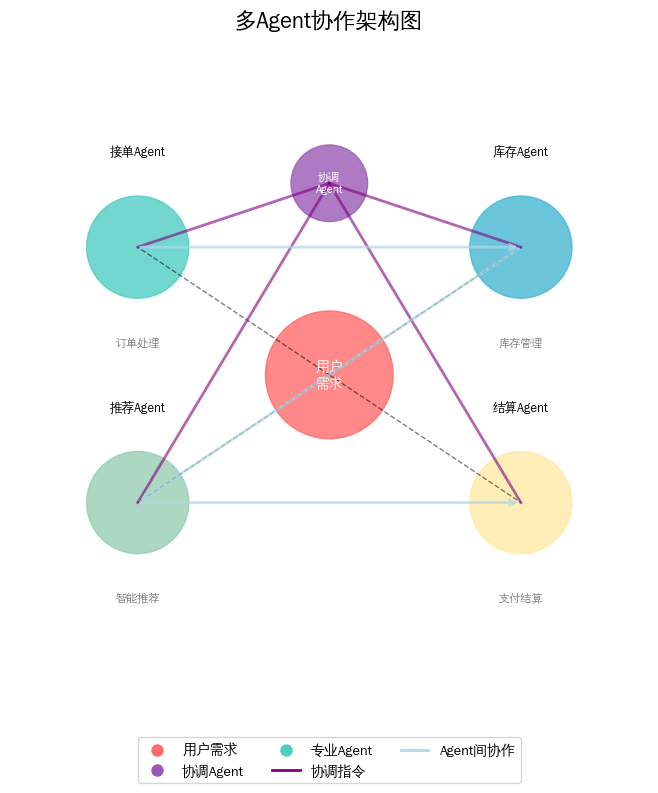


📊 协作模式性能对比：


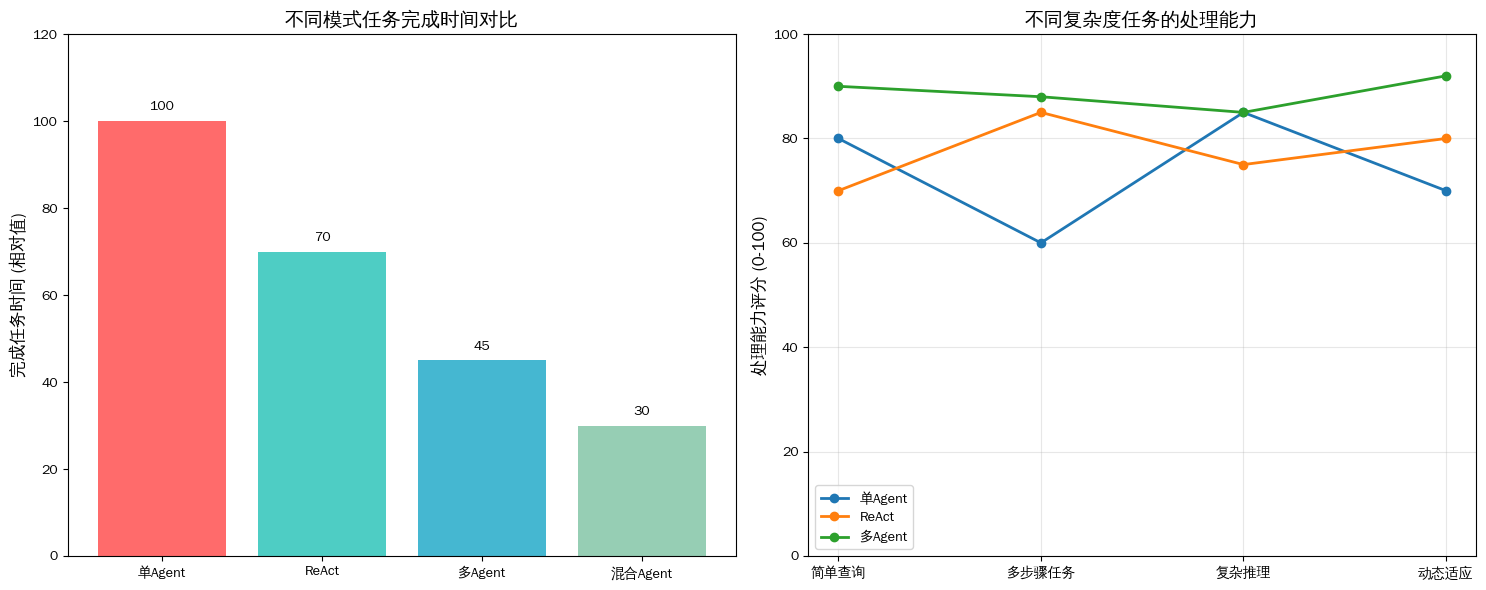

In [6]:
# 可视化多Agent协作过程
def plot_multiagent_collaboration():
    """可视化多Agent协作的场景"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 中心：用户需求
    center_circle = plt.Circle((0.5, 0.5), 0.1, color='#FF6B6B', alpha=0.8)
    ax.add_patch(center_circle)
    ax.text(0.5, 0.5, '用户\n需求', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # 四个Agent分布
    agent_positions = [(0.2, 0.7), (0.8, 0.7), (0.2, 0.3), (0.8, 0.3)]
    agent_colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    agent_names = ['接单Agent', '库存Agent', '推荐Agent', '结算Agent']
    agent_roles = ['订单处理', '库存管理', '智能推荐', '支付结算']
    
    for i, (pos, color, name, role) in enumerate(zip(agent_positions, agent_colors, agent_names, agent_roles)):
        # Agent圆圈
        agent_circle = plt.Circle(pos, 0.08, color=color, alpha=0.8)
        ax.add_patch(agent_circle)
        
        # Agent名称和角色
        ax.text(pos[0], pos[1] + 0.15, name, ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(pos[0], pos[1] - 0.15, role, ha='center', va='center', fontsize=8, color='gray')
        
        # 连接线
        ax.plot([0.5, pos[0]], [0.5, pos[1]], 'k--', alpha=0.5, linewidth=1)
        
        # 协作箭头
        if i < len(agent_positions) - 1:
            next_pos = agent_positions[i + 1]
            ax.annotate('', xy=next_pos, xytext=pos,
                       arrowprops=dict(arrowstyle='->', lw=2, color='lightblue', alpha=0.7))
    
    # 主控Agent（协调者）
    coord_pos = (0.5, 0.8)
    coord_circle = plt.Circle(coord_pos, 0.06, color='#9B59B6', alpha=0.8)
    ax.add_patch(coord_circle)
    ax.text(coord_pos[0], coord_pos[1], '协调\nAgent', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    # 协调器到各个Agent的连接
    for pos in agent_positions:
        ax.plot([coord_pos[0], pos[0]], [coord_pos[1], pos[1]], 'purple', alpha=0.6, linewidth=2)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('多Agent协作架构图', fontsize=16, fontweight='bold', pad=20)
    
    # 添加图例
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=10, label='用户需求'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=10, label='协调Agent'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4', markersize=10, label='专业Agent'),
        plt.Line2D([0], [0], color='purple', linewidth=2, label='协调指令'),
        plt.Line2D([0], [0], color='lightblue', linewidth=2, label='Agent间协作')
    ]
    ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.tight_layout()
    plt.show()

# 可视化不同协作模式的性能对比
def plot_collaboration_performance():
    """对比不同协作模式的性能"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 任务完成时间对比
    models = ['单Agent', 'ReAct', '多Agent', '混合Agent']
    completion_times = [100, 70, 45, 30]  # 相对时间
    
    bars1 = ax1.bar(models, completion_times, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    ax1.set_ylabel('完成任务时间 (相对值)', fontsize=12)
    ax1.set_title('不同模式任务完成时间对比', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 120)
    
    # 添加数值标签
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height}', ha='center', va='bottom', fontsize=10)
    
    # 任务处理能力对比
    complex_tasks = ['简单查询', '多步骤任务', '复杂推理', '动态适应']
    
    for i, model in enumerate(['单Agent', 'ReAct', '多Agent']):
        performance = [80, 60, 85, 70] if model == '单Agent' else \
                      [70, 85, 75, 80] if model == 'ReAct' else \
                      [90, 88, 85, 92]
        
        ax2.plot(complex_tasks, performance, marker='o', linewidth=2, label=model)
    
    ax2.set_ylabel('处理能力评分 (0-100)', fontsize=12)
    ax2.set_title('不同复杂度任务的处理能力', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

print("📊 多Agent协作架构可视化：")
plot_multiagent_collaboration()

print("\n📊 协作模式性能对比：")
plot_collaboration_performance()

In [11]:
# 实战练习：ReAct模式在电商场景中的应用
def create_ecommerce_react_example():
    """电商场景的ReAct模式应用示例"""
    print("🛒 电商ReAct应用示例\n" + "=" * 50)
    
    # 创建电商ReAct Agent
    class EcommerceReactAgent:
        def __init__(self):
            self.tools = {
                "商品搜索": self.search_products,
                "库存查询": self.check_inventory,
                "价格计算": self.calculate_price,
                "库存确认": self.confirm_inventory,
                "生成订单": self.create_order
            }
            self.selected_products = []
        
        def search_products(self, query):
            products = [
                {"name": "红豆沙", "price": 12, "id": "P001"},
                {"name": "绿豆沙", "price": 10, "id": "P002"},
                {"name": "银耳莲子", "price": 15, "id": "P003"},
                {"name": "杨枝甘露", "price": 18, "id": "P004"}
            ]
            result = [p for p in products if query.lower() in p["name"].lower()]
            self.selected_products = result
            return result
        
        def check_inventory(self, product_id):
            inventory = {
                "P001": 10,
                "P002": 15,
                "P003": 8,
                "P004": 5
            }
            return inventory.get(product_id, 0)
        
        def calculate_price(self, products):
            total = sum(p["price"] for p in products)
            return total
        
        def confirm_inventory(self, products):
            low_stock = []
            for product in products:
                inventory = self.check_inventory(product["id"])
                if inventory < 3:
                    low_stock.append(product["name"])
            return low_stock
        
        def create_order(self, products, total_price):
            return f"✅ 订单创建成功！共{len(products)}件商品，总价¥{total_price}"
        
        def react_step(self, user_input, context=None):
            """执行ReAct推理步骤"""
            print(f"\n🧠 用户输入: {user_input}")
            
            # 分析用户意图
            if "搜索" in user_input or "找" in user_input:
                tool = "商品搜索"
                param = user_input.split("搜索")[-1].strip() or user_input.split("找")[-1].strip()
            elif "库存" in user_input:
                tool = "库存查询"
                param = user_input.split("库存")[-1].strip()
            elif "计算" in user_input or "多少钱" in user_input:
                tool = "价格计算"
                param = self.selected_products
            elif "订单" in user_input:
                tool = "生成订单"
                param = None
            else:
                print("❌ 无法理解用户意图")
                return None
            
            print(f"💭 推理: 需要使用工具 '{tool}'")
            
            if tool in self.tools:
                if tool == "生成订单":
                    if not self.selected_products:
                        result = "❌ 没有选中的商品，无法生成订单"
                    else:
                        total = self.calculate_price(self.selected_products)
                        result = self.tools[tool](self.selected_products, total)
                elif param is not None:
                    result = self.tools[tool](param)
                else:
                    result = self.tools[tool]()
                print(f"🔧 执行: {tool} → {result}")
                return result
            else:
                print(f"❌ 未知工具: {tool}")
                return None

    # 测试电商ReAct流程
    agent = EcommerceReactAgent()
    
    # 模拟用户对话流程
    conversation = [
        "我想搜索红豆沙",
        "红豆沙的库存还有多少？",
        "把红豆沙和绿豆沙都买一份，算算多少钱",
        "帮我生成订单"
    ]
    
    for user_input in conversation:
        result = agent.react_step(user_input)
        if result:
            print(f"📋 结果: {result}\n")
        
    print("\n🎉 电商ReAct流程完成！")

# 执行电商ReAct示例
create_ecommerce_react_example()

🛒 电商ReAct应用示例

🧠 用户输入: 我想搜索红豆沙
💭 推理: 需要使用工具 '商品搜索'
🔧 执行: 商品搜索 → [{'name': '红豆沙', 'price': 12, 'id': 'P001'}]
📋 结果: [{'name': '红豆沙', 'price': 12, 'id': 'P001'}]


🧠 用户输入: 红豆沙的库存还有多少？
💭 推理: 需要使用工具 '库存查询'
🔧 执行: 库存查询 → 0

🧠 用户输入: 把红豆沙和绿豆沙都买一份，算算多少钱
💭 推理: 需要使用工具 '价格计算'
🔧 执行: 价格计算 → 12
📋 结果: 12


🧠 用户输入: 帮我生成订单
💭 推理: 需要使用工具 '生成订单'
🔧 执行: 生成订单 → ✅ 订单创建成功！共1件商品，总价¥12
📋 结果: ✅ 订单创建成功！共1件商品，总价¥12


🎉 电商ReAct流程完成！


## 📝 练习题和思考题

### 实践练习

1. **动手实现ReAct Agent**：修改上面的`ReactAgent`类，让它能够处理更复杂的任务，比如数学计算题。

2. **设计多Agent系统**：为你的业务场景设计一个多Agent系统，确定需要哪些专业Agent，它们如何协作。

3. **性能优化**：分析多Agent系统的性能瓶颈，思考如何优化Agent间的通信效率。

### 思考题

1. **ReAct的局限性**：ReAct模式在哪些场景下可能失效？如何改进？

2. **多Agent挑战**：多Agent系统中如何处理Agent间的冲突和竞争？

3. **现实应用**：在你的实际业务中，哪些场景最适合用ReAct或多Agent？为什么？

## 🎬 推荐学习资源

### 📹 视频推荐
1. **ReAct Agent 智能体教程**（10分钟）
   https://www.bilibili.com/video/BV1QmNX6UEWN/
   > 简介：10分钟完整梳理 ReAct 运行逻辑与落地实践，适合快速理解核心机制

2. **ReAct：协同 Agent 推理与行动**（一起啃书系列）
   https://www.bilibili.com/video/BV1qzNAerELM/
   > 简介：逐行解读 ReAct 论文与 LangChain 实现代码，适合想深入源码的同学

### 📖 延伸阅读
1. **ReAct: Synergizing Reasoning and Acting in Language Models（论文）**
   https://react-lm.github.io/
   > 简介：ReAct 范式原始论文，奠定了"推理+行动"交替执行的 Agent 基石

2. **ReAct Agent 终极指南**
   https://juejin.cn/post/7518707715129688064
   > 简介：掘金实战文章，涵盖 LangChain 实现、多工具调度、幻觉消除等进阶内容


## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **ReAct** | /riˈækt/ | 推理+行动，想一步做一步 |
| **Thought** | /θɔːt/ | 思考，模型分析该做什么 |
| **Action** | /ˈækʃən/ | 行动，调用工具或执行操作 |
| **Observation** | /ˌɒbzəˈveɪʃən/ | 观察，工具执行后的反馈结果 |
| **Multi-Agent** | /ˈmʌlti ˈeɪdʒənt/ | 多智能体，多个Agent分工合作 |
| **Orchestration** | /ˌɔːkɪˈstreɪʃən/ | 编排，协调多Agent工作流程 |
| **Planning** | /ˈplænɪŋ/ | 规划，先想计划再动手 |
| **Reflection** | /rɪˈflekʃən/ | 反思，回顾步骤判断方向对不对 |
| **Delegation** | /ˌdelɪˈɡeɪʃən/ | 委托，主Agent分配子任务 |
| **Pipeline** | /ˈpaɪplaɪn/ | 流水线，上一步输出是下一步输入 |